In [23]:
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
from rasterio import open as rio_open
from rasterio.mask import mask

In [24]:

cwd_path = Path.cwd()   
repo_path = cwd_path.parent
data_path = repo_path/'data'
local_data_path = Path('C:/data')

In [25]:
# Create envelope around the network
ls_station_path = local_data_path.joinpath("raw", "StedinData", "Laagspanningsstations")
msls_station_path = local_data_path.joinpath("raw", "StedinData", "MiddenLaagspanningsstations")
ms_station_path = local_data_path.joinpath("raw", "StedinData", "Middenspanningsstations")

ls_lines_path = local_data_path.joinpath("raw", "StedinData", "Laagspanningsverbindingen")
ms_lines_path = local_data_path.joinpath("raw", "StedinData", "Middenspanningsverbindingen")

raw_paths = [ls_station_path,msls_station_path,ms_station_path, 
             ls_lines_path, ms_lines_path]

for path in raw_paths:
    assert path.exists(), f"Path {path} does not exist"


In [26]:
# load road network, find bounding box, and clip electricity stations to the bounding box
road_network_path = data_path / 'static' / 'network' / 'try_study_area_larger.shp'
road_network = gpd.read_file(road_network_path)
bounding_box = road_network.union_all().envelope    

In [27]:
road_network.explore()

In [28]:
# load the shapefiles and clip to the bounding box
ls_stations = gpd.read_file(ls_station_path/'Laagspanningsstations.shp')
ls_stations = ls_stations.to_crs(road_network.crs)  # Ensure CRS matches
ls_stations = ls_stations.clip(bounding_box)
msls_stations = gpd.read_file(msls_station_path/'MiddenLaagspanningsstations.shp')
msls_stations = msls_stations.to_crs(road_network.crs)
msls_stations = msls_stations.clip(bounding_box)
ms_stations = gpd.read_file(ms_station_path/'Middenspanningsstations.shp')
ms_stations = ms_stations.to_crs(road_network.crs)  # Ensure CRS matches
ms_stations = ms_stations.clip(bounding_box)

In [29]:
# save to repo data folder
ls_stations.to_file(data_path/'electricity'/'ls_stations_clipped.shp')
msls_stations.to_file(data_path/'electricity'/'msls_stations_clipped.shp')
ms_stations.to_file(data_path/'electricity'/'ms_stations_clipped.shp')

In [30]:
# load the power lines too
ls_lines = gpd.read_file(ls_lines_path/'Laagspanningsverbindingen.shp')
ls_lines = ls_lines.to_crs(road_network.crs)  # Ensure CRS matches
ms_lines = gpd.read_file(ms_lines_path/'Middenspanningsverbindingen.shp')
ms_lines = ms_lines.to_crs(road_network.crs)  # Ensure CRS matches


In [31]:
# for the power lines, create a buffered bounding box with a 15% area in each direction
# find the width and height of the bounding box
minx, miny, maxx, maxy = bounding_box.bounds
bbox_width = maxx - minx
bbox_height = maxy - miny
# calculate the buffer size as 15% of the width and height
buffer_size_x = bbox_width * 0.15
buffer_size_y = bbox_height * 0.15
# pick the largest of the two buffer sizes
buffer_size = max(buffer_size_x, buffer_size_y)
# create a buffered bounding box
buffered_bounding_box = bounding_box.buffer(buffer_size)
# clip the power lines to the buffered bounding box
ls_lines = ls_lines.clip(buffered_bounding_box)
ms_lines = ms_lines.clip(buffered_bounding_box)

In [32]:
# ms_lines.explore()

In [33]:
# save the clipped power lines to the repo data folder
ls_lines.to_file(data_path/'electricity'/'ls_lines_clipped.shp')
ms_lines.to_file(data_path/'electricity'/'ms_lines_clipped.shp')

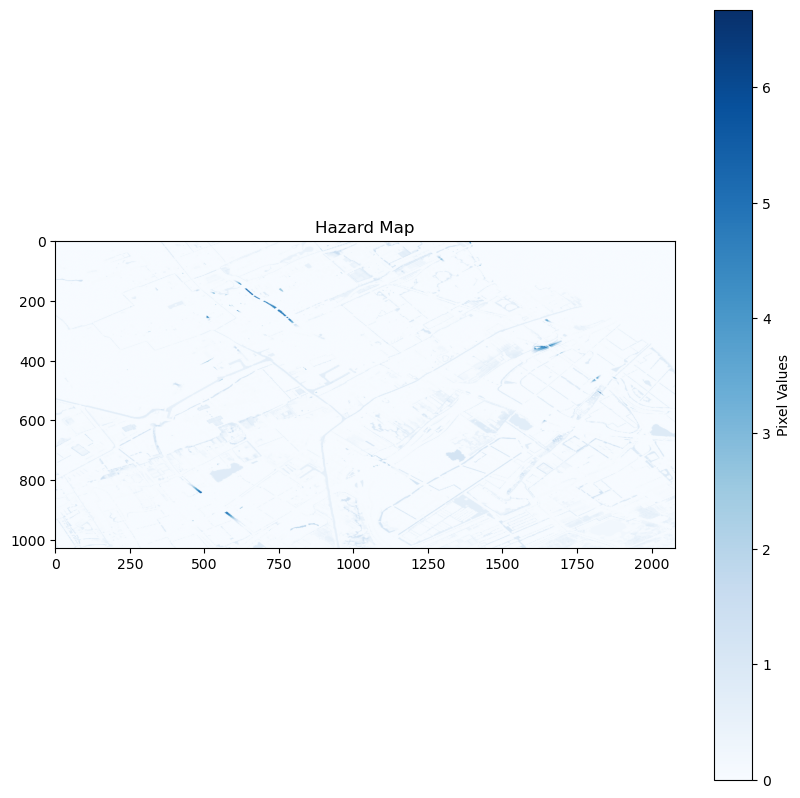

In [34]:
# clip hazard map
hazard_map_path = data_path / 'static/hazard/processed/delfland_ghg200m_wgs84_processed.tif'
assert hazard_map_path.exists(), f"Path {hazard_map_path} does not exist"


with rio_open(hazard_map_path) as src:
    hazard_map = src.read(1)
    hazard_transform = src.transform
    hazard_crs = src.crs
    
    # Reproject bounding_box to hazard_crs using GeoSeries
    bounding_box_gs = gpd.GeoSeries([bounding_box], crs=road_network.crs)
    bounding_box_haz_crs = bounding_box_gs.to_crs(hazard_crs).iloc[0]
    hazard_map_clipped, hazard_transform_clipped = mask(src, [bounding_box_haz_crs], crop=True)

# plot the hazard map
plt.figure(figsize=(10, 10))
plt.imshow(hazard_map_clipped[0], cmap='Blues', vmin=0) # no data values are large negatives, so adjust the colormap 
plt.colorbar(label='Pixel Values')  
plt.title('Hazard Map')
plt.show()


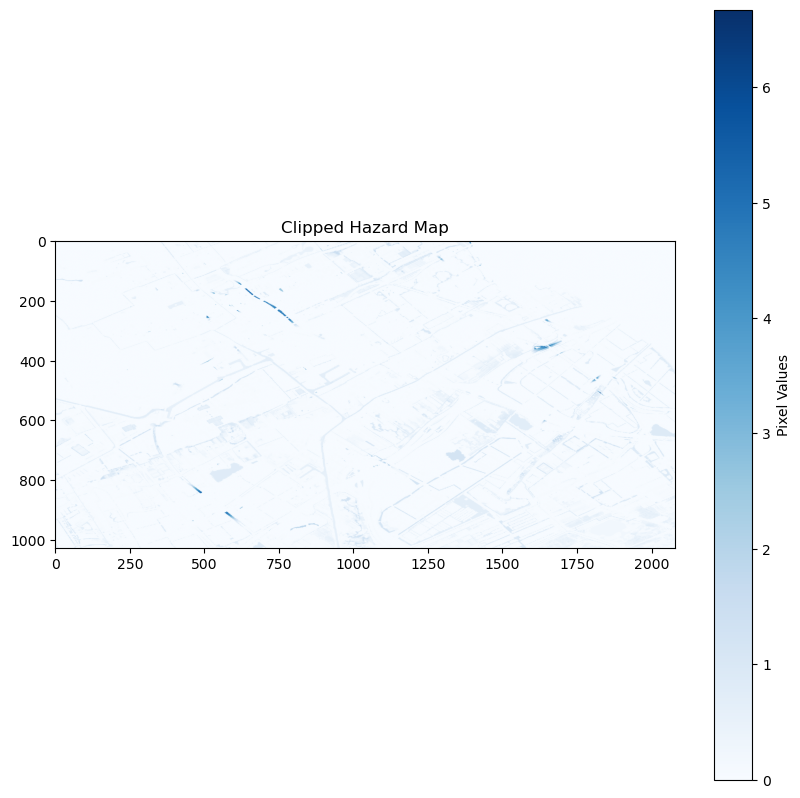

In [35]:
# save the clipped hazard map
clipped_hazard_map_path = data_path / 'static' / 'hazard' / 'processed' / 'clipped_hazard_map_larger.tif'
with rio_open(clipped_hazard_map_path, 'w', driver='GTiff',
             height=hazard_map_clipped.shape[1], width=hazard_map_clipped.shape[2],
             count=1, dtype=hazard_map_clipped.dtype,
             crs=hazard_crs, transform=hazard_transform_clipped) as dst:
    dst.write(hazard_map_clipped[0], 1)

# load the clipped hazard map
clipped_hazard_map = rio_open(clipped_hazard_map_path)
# plot the clipped hazard map
plt.figure(figsize=(10, 10))
plt.imshow(clipped_hazard_map.read(1), cmap='Blues', vmin=0)  # Change the colormap if desired
plt.colorbar(label='Pixel Values')
plt.title('Clipped Hazard Map')
plt.show()

In [36]:
# Create artificial timestep maps where day 0 is half the intensity of the basline map, day 1 is the baseline map, and day 2 is half the intensity of the baseline map, day 3-7 is no flooding
timesteps = range(8)  # 0 to 7 inclusive
timestep_maps = {}
for timestep in timesteps:
    if timestep == 0:
        timestep_maps[timestep] = clipped_hazard_map.read(1) * 0.5  # Half intensity
    elif timestep == 1:
        timestep_maps[timestep] = clipped_hazard_map.read(1)  # Baseline
    elif timestep == 2:
        timestep_maps[timestep] = clipped_hazard_map.read(1) * 0.5  # Half intensity
    else:
        timestep_maps[timestep] = clipped_hazard_map.read(1) * 0  # No flooding


In [37]:
# save the timestep maps
timestep_map_dir = data_path / 'static' / 'hazard' / 'processed' / 'timesteps'

for timestep, map_data in timestep_maps.items():
    if timestep < 10:
        filename = f"clipped_hazard_map_0{timestep}.tif"
    else:
        filename = f"clipped_hazard_map_{timestep}.tif"
    filepath = timestep_map_dir / filename
    with rio_open(filepath, 'w', driver='GTiff',
                 height=map_data.shape[0], width=map_data.shape[1],
                 count=1, dtype=map_data.dtype,
                 crs=clipped_hazard_map.crs, transform=clipped_hazard_map.transform) as dst:
        dst.write(map_data, 1)